<br>
<html>
  <body>
    <header></header>
        <CENTER>
          <img src="https://uvv.br/wp-content/themes/core/dist/images/Logo@2x.png" alt="UVV-LOGO" style = width="100px"; height="100px">
        </CENTER>
        <CENTER><b>ANÁLISE EXPLORATÓRIA DOS DADOS</b></CENTER>
        <CENTER><b>ANÁLISE QUANTITATIVA</b></CENTER>
        </font>
  </body>
</html>

**NOME:** Isabela Carone Lacerda

# BIBLIOTECAS E FUNÇÕES

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

In [ ]:
def statistic(_dataset):
    """
      Compute descriptive statistics for a numerical dataset.

      This function extends the standard pandas `describe()` method
      by removing the count metric and adding:
      - Range (max - min)
      - Mode

      The output is a table of descriptive statistics commonly used
      in Exploratory Data Analysis (EDA).

      Parameters
      ----------
      _dataset : pandas.Series or pandas.DataFrame
          Input dataset containing numerical values.

      Returns
      -------
      pandas.DataFrame
          A DataFrame with descriptive statistics (excluding count),
          including range and mode, sorted and rounded to two decimals.
    """

    # Generate basic descriptive statistics using pandas
    # (count, mean, std, min, quartiles, and max)
    _describe = _dataset.describe()

    # Remove the 'count' row, as it is not used in this analysis
    _describe = _describe.drop('count')

    # Compute the range for each numerical column
    # Range = maximum value minus minimum value
    _describe.loc['range'] = _describe.loc['max'] - _describe.loc['min']

    # Compute the mode for each numerical column
    # stats.mode returns both mode and frequency;
    # [0] extracts only the modal value
    _describe.loc['mode'] = stats.mode(
        _dataset,
        keepdims=False,
        nan_policy='omit'
    )[0]

    # Sort the statistics (index) and round all values to two decimal places
    _describe = np.around(_describe.sort_values(), 2)

    # Return the final descriptive statistics table
    return _describe

In [ ]:
def PlotarStatistic(dataset, yLabel=None):
    """
      Plot descriptive statistics of a dataset and highlight
      measures of central tendency (mean, median, and mode).

      This function computes descriptive statistics using a
      previously defined `statistic()` function, generates
      a plot with summary measures, and prints the numerical
      descriptive table.

      Parameters
      ----------
      dataset : pandas.Series or pandas.DataFrame
          Input dataset containing numerical values.
          It is expected that the statistic() function
          can process this object.

      yLabel : str, optional
          Label for the y-axis of the plot.

      Returns
      -------
      None
          Displays a plot and prints descriptive statistics.
    """

    # Compute descriptive statistics using a custom function
    _describe = statistic(dataset)

    # -------------------------------------------------------
    # Construction of LaTeX-formatted labels for statistics
    # -------------------------------------------------------

    # Mean (population notation: overline mu)
    # Raw string (r'') avoids invalid escape sequence warnings
    mean_mu = r'MÉDIA:  $\overline{\mu}$ = '
    mean_mu += f'{_describe["mean"]: .2f}'  # Numeric value formatted to 2 decimals

    # Median (tilde mu)
    median_mu = r'MEDIANA: $\tilde{\mu}$ = '
    median_mu += f'{_describe["50%"]: .2f}'

    # Mode (hat mu)
    mode_mu = r'MODA: $\hat{\mu}$ = '
    mode_mu += f'{_describe["mode"]: .2f}'

    # New line separator for legend text composition
    enter = '\n'

    # Concatenated label containing all summary measures
    label = mean_mu + enter + median_mu + enter + mode_mu

    # -------------------------------------------------------
    # Plotting section
    # -------------------------------------------------------

    # Apply the statistic function as an aggregation and plot the result
    # (Assumes dataset supports aggregation and plotting)
    dataset.agg(statistic).plot(
        figsize=[15, 6],
        label='MEDIDAS DE RESUMO: '
    )

    # Plot the mean marker at its corresponding index position
    plt.plot(
        list(_describe.index).index('mean'),
        _describe["mean"],
        'D',
        label=mean_mu
    )

    # Plot the median marker
    plt.plot(
        list(_describe.index).index('50%'),
        _describe["50%"],
        'D',
        label=median_mu
    )

    # Plot the mode marker
    plt.plot(
        list(_describe.index).index('mode'),
        _describe["mode"],
        'D',
        label=mode_mu
    )

    # Set plot title
    plt.title('ESTATÍSTICA DESCRITIVA DO DATASET')

    # Display legend with statistical labels
    plt.legend()

    # Set y-axis label if provided
    plt.ylabel(yLabel)

    # Render the plot
    plt.show()

    # -------------------------------------------------------
    # Textual output
    # -------------------------------------------------------

    # Print descriptive statistics table
    print('ESTATÍSTICA DESCRITIVA DO DATASET:')
    print(_describe)

##LOAD

In [ ]:
# LOAD DO DATASET
table = pd.read_csv('/content/table16.csv', index_col=0) # vira df aqui

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios'
print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['atividade1.html', 'atividade1.ipynb', 'atividade 3.ipynb', 'atividade2.ipynb']


In [ ]:
print(type(table))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
table.head()

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,6876333,SUL,MASCULINO,SOLTEIRO,1,3336.84,"Serviço eficiente, recomendo o clube: UVVine",68.680,12.929435,2.447630,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,5677339,SUDESTE,MASCULINO,CASADO,2,3453.34,"Serviço eficiente, recomendo o clube: UVVine",68.680,13.993214,1.393874,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,1104271,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,"Serviço impecável, adorei o clube: UVVine",68.680,11.161985,3.471322,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02
3,2691016,SUL,FEMININO,CASADO,1,26192.61,"Serviço eficiente, recomendo o clube: UVVine",77.972,13.361280,1.463516,...,1.991469,0.235816,0.607276,0.835639,3.284154,1.078509,1.955873,994.797550,PRIME,3930.88
4,6636530,CENTRO-OESTE,MASCULINO,SOLTEIRO,1,21792.17,Entrega foi boa e rápida na UVVine,68.680,13.536534,3.832572,...,2.269030,1.487258,0.222171,1.445279,4.178987,0.988953,1.591512,377.293171,PRIME,873.68


## FAZER AS QUESTÕES AQUI:

In [ ]:
def normalChart(
    table: pd.DataFrame,
    yLabel: str = None
    ) -> None:
    """
    Gera o gráfico da distribuição de uma variável quantitativa contínua.

    O gráfico contém:
    - Histograma com curva KDE
    - Título com o nome da variável e a quantidade de bins
    - Legenda com:
        - Coeficiente de Variação
        - Coeficiente de Assimetria
        - Coeficiente de Curtose
    - Linhas verticais para:
        - Média
        - Moda
        - Mediana

    Após o gráfico, exibe automaticamente um diagnóstico detalhado
    da distribuição com base nas métricas calculadas.

    Args:
        table (pd.DataFrame): Dataset de entrada.
        yLabel (str): Nome da variável quantitativa contínua.
    """

    serie = pd.to_numeric(table[yLabel], errors="coerce").dropna()

    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode().iloc[0]
    desvio_padrao = serie.std(ddof=1)

    if media != 0:
        coef_variacao = (desvio_padrao / media) * 100
    else:
        coef_variacao = np.nan

    coef_assimetria = stats.skew(serie, bias=False)
    coef_curtose = stats.kurtosis(serie, fisher=False, bias=False)

    bins = int(np.sqrt(len(serie)))

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    sns.histplot(
        serie,
        bins=bins,
        kde=True,
        stat="density",
        edgecolor="black",
        alpha=0.6
    )

    plt.axvline(media, color="red", linestyle="--", linewidth=2, label=f"Média = {media:.2f}")
    plt.axvline(mediana, color="green", linestyle="--", linewidth=2, label=f"Mediana = {mediana:.2f}")
    plt.axvline(moda, color="purple", linestyle="--", linewidth=2, label=f"Moda = {moda:.2f}")

    legenda_metricas = (
        f"CV = {coef_variacao:.2f}%\n"
        f"Assimetria = {coef_assimetria:.2f}\n"
        f"Curtose = {coef_curtose:.2f}"
    )

    plt.title(f"{yLabel} | bins = {bins}", fontsize=14, fontweight="bold")
    plt.xlabel(yLabel)
    plt.ylabel("Densidade")
    plt.legend(title=legenda_metricas)
    plt.show()

    print(f"--- Diagnóstico da Distribuição: {yLabel} ---")

    if np.isnan(coef_variacao):
        print("Coeficiente de Variação: não pode ser interpretado, pois a média é zero.")
    elif coef_variacao < 15:
        print(f"Coeficiente de Variação = {coef_variacao:.2f}% -> baixa dispersão.")
    elif coef_variacao < 30:
        print(f"Coeficiente de Variação = {coef_variacao:.2f}% -> dispersão moderada.")
    else:
        print(f"Coeficiente de Variação = {coef_variacao:.2f}% -> alta dispersão.")

    if abs(coef_assimetria) < 0.5:
        print(f"Coeficiente de Assimetria = {coef_assimetria:.2f} -> distribuição aproximadamente simétrica.")
    elif coef_assimetria > 0:
        print(f"Coeficiente de Assimetria = {coef_assimetria:.2f} -> assimetria à direita.")
    else:
        print(f"Coeficiente de Assimetria = {coef_assimetria:.2f} -> assimetria à esquerda.")

    if np.isclose(coef_curtose, 3, atol=0.3):
        print(f"Coeficiente de Curtose = {coef_curtose:.2f} -> distribuição mesocúrtica.")
    elif coef_curtose > 3:
        print(f"Coeficiente de Curtose = {coef_curtose:.2f} -> distribuição leptocúrtica.")
    else:
        print(f"Coeficiente de Curtose = {coef_curtose:.2f} -> distribuição platicúrtica.")

    if abs(coef_assimetria) < 0.5 and np.isclose(coef_curtose, 3, atol=0.5):
        print("Conclusão: a distribuição se aproxima de uma normal.")
    else:
        print("Conclusão: a distribuição não se aproxima fortemente de uma normal.")

    print("\n")

def analyze_all_quantitative(
    table: pd.DataFrame
    ) -> None:
    """
    Aplica a função normalChart a todas as colunas numéricas do dataset.

    Args:
        table (pd.DataFrame): Dataset de entrada.
    """

    colunas_numericas = table.select_dtypes(include=np.number).columns

    for coluna in colunas_numericas:
        print("=" * 70)
        print(f"Variável analisada: {coluna}")
        print("=" * 70)
        normalChart(table, coluna)

In [ ]:
def dropOutliers(
    table: pd.DataFrame,
    yLabel: str = None
    ) -> pd.DataFrame:
    """
    Remove outliers de uma variável quantitativa utilizando o método do IQR.

    Limites:
    - Inferior = Q1 - 1.5 * IQR
    - Superior = Q3 + 1.5 * IQR

    Args:
        table (pd.DataFrame): Dataset de entrada.
        yLabel (str): Nome da variável quantitativa.

    Returns:
        pd.DataFrame: Novo dataset sem os outliers da variável informada.
    """

    serie = pd.to_numeric(table[yLabel], errors="coerce")

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    table_sem_outliers = table[
        (serie >= limite_inferior) &
        (serie <= limite_superior)
    ].copy()

    return table_sem_outliers

In [ ]:
def analyze_after_outlier_removal(
    table: pd.DataFrame,
    colunas: list
    ) -> pd.DataFrame:
    """
    Remove outliers sucessivamente das colunas informadas e,
    depois, exibe a análise gráfica de cada uma delas.

    Args:
        table (pd.DataFrame): Dataset de entrada.
        colunas (list): Lista de colunas quantitativas para remoção de outliers.

    Returns:
        pd.DataFrame: Dataset sem outliers das colunas informadas.
    """

    table_limpa = table.copy()

    for coluna in colunas:
        table_limpa = dropOutliers(table_limpa, coluna)

    print("--- Dataset após remoção de outliers ---")
    print(f"Quantidade de linhas restante: {len(table_limpa)}")
    print("\n")

    for coluna in colunas:
        print("=" * 70)
        print(f"Análise após remoção de outliers: {coluna}")
        print("=" * 70)
        normalChart(table_limpa, coluna)

    return table_limpa

#Questão 1:

Faça uma função (**def + docstring**) que crie um gráfico da distribuição normal de uma variável quantitativa contínua qualquer, sendo que este gráfico deve conter:

*   No título, o Nome da variável (yLabel) + número de bins
*   Uma Legenda com as métricas:
  
  * Coeficiente de Variação
  * Coeficiente de Assimetria
  * Coeficiente de Curtose

* Uma linha vertical para as 3 medidas: Média, Moda e Mediana

Após o gráfico, exibir automaticamente o diagnóstico detalhado de análise da distribuição normal baseado nas métricas calculadas (Coeficiente de Variação, Coeficiente de Assimetria e Coeficiente de Curtose).

Protótipo da função:

  * **def** normalChart(table, yLabel = None)

Aplicar a TODAS as colunas (variável quantitativa contínua):

Variável analisada: NOTA FISCAL


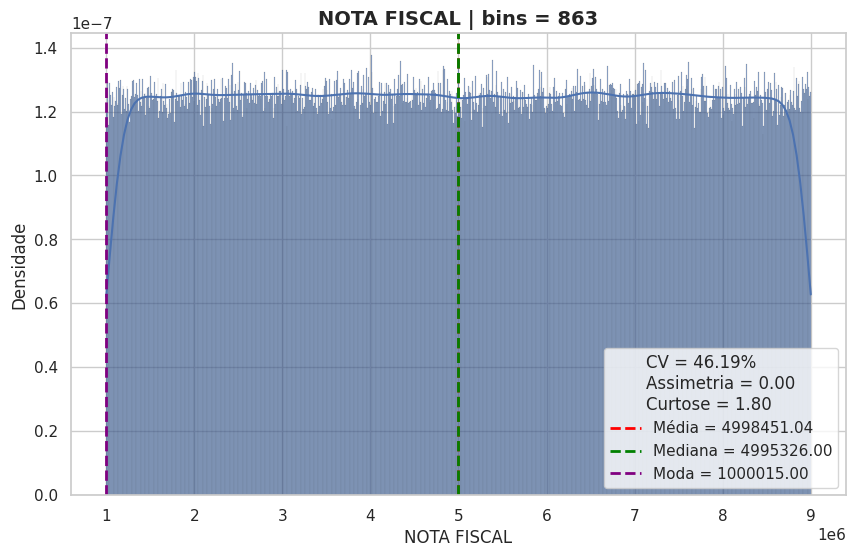

--- Diagnóstico da Distribuição: NOTA FISCAL ---
Coeficiente de Variação = 46.19% -> alta dispersão.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 1.80 -> distribuição platicúrtica.
Conclusão: a distribuição não se aproxima fortemente de uma normal.


Variável analisada: DEPENDENTES


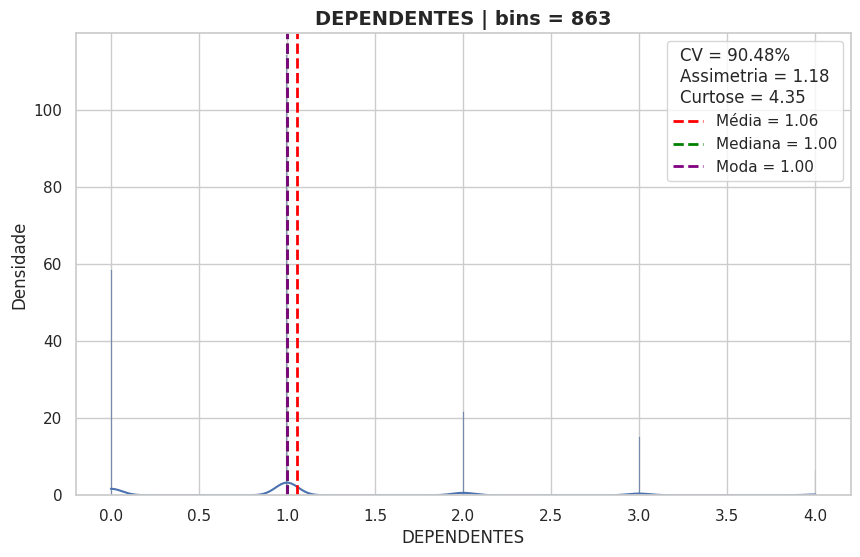

--- Diagnóstico da Distribuição: DEPENDENTES ---
Coeficiente de Variação = 90.48% -> alta dispersão.
Coeficiente de Assimetria = 1.18 -> assimetria à direita.
Coeficiente de Curtose = 4.35 -> distribuição leptocúrtica.
Conclusão: a distribuição não se aproxima fortemente de uma normal.


Variável analisada: RENDA BRUTO (R$)


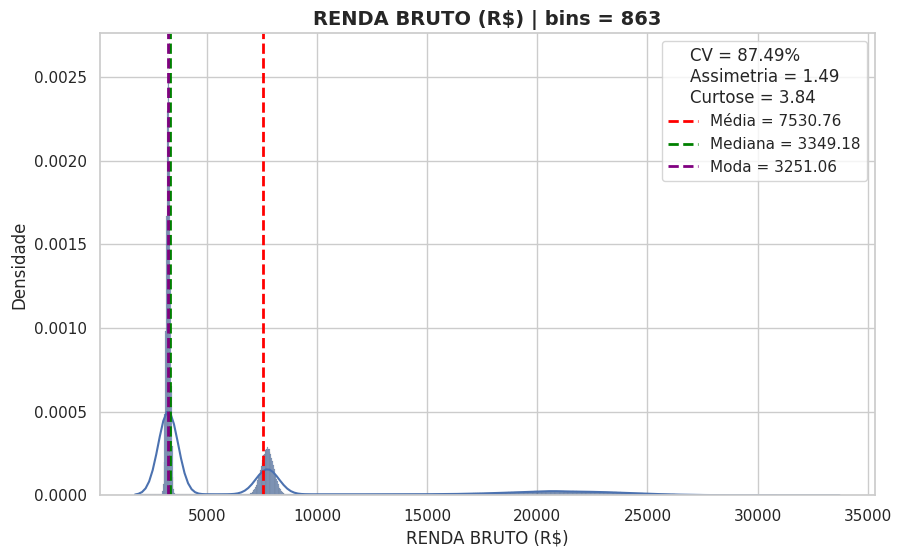

--- Diagnóstico da Distribuição: RENDA BRUTO (R$) ---
Coeficiente de Variação = 87.49% -> alta dispersão.
Coeficiente de Assimetria = 1.49 -> assimetria à direita.
Coeficiente de Curtose = 3.84 -> distribuição leptocúrtica.
Conclusão: a distribuição não se aproxima fortemente de uma normal.


Variável analisada: NOTA DE SATISFAÇÃO (%)


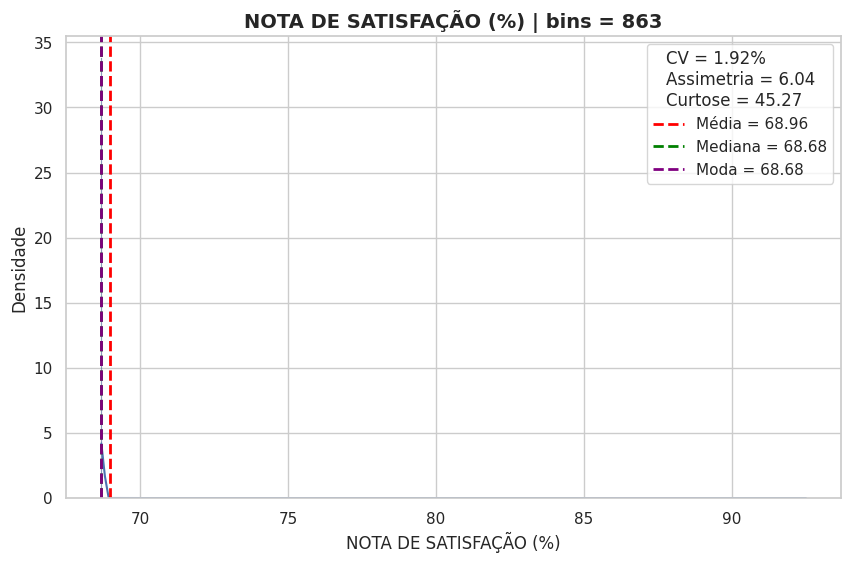

--- Diagnóstico da Distribuição: NOTA DE SATISFAÇÃO (%) ---
Coeficiente de Variação = 1.92% -> baixa dispersão.
Coeficiente de Assimetria = 6.04 -> assimetria à direita.
Coeficiente de Curtose = 45.27 -> distribuição leptocúrtica.
Conclusão: a distribuição não se aproxima fortemente de uma normal.


Variável analisada: MEAN: alcohol


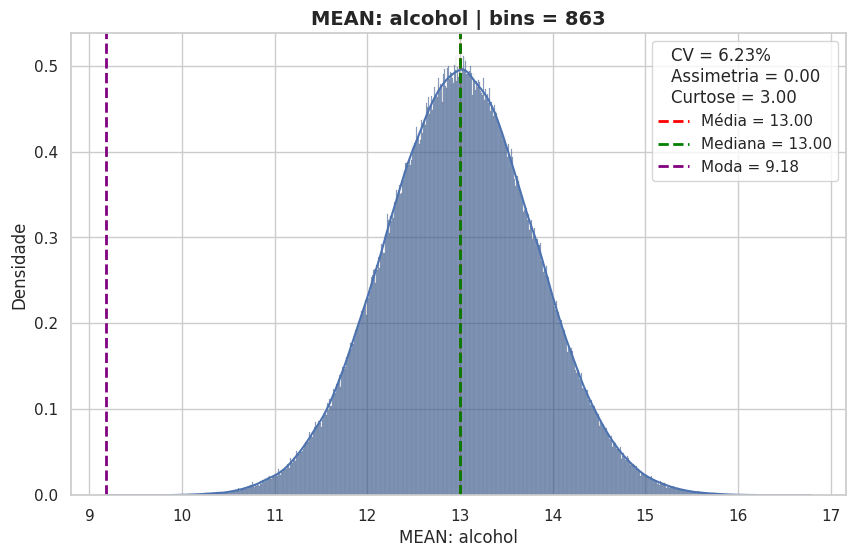

--- Diagnóstico da Distribuição: MEAN: alcohol ---
Coeficiente de Variação = 6.23% -> baixa dispersão.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: malic_acid


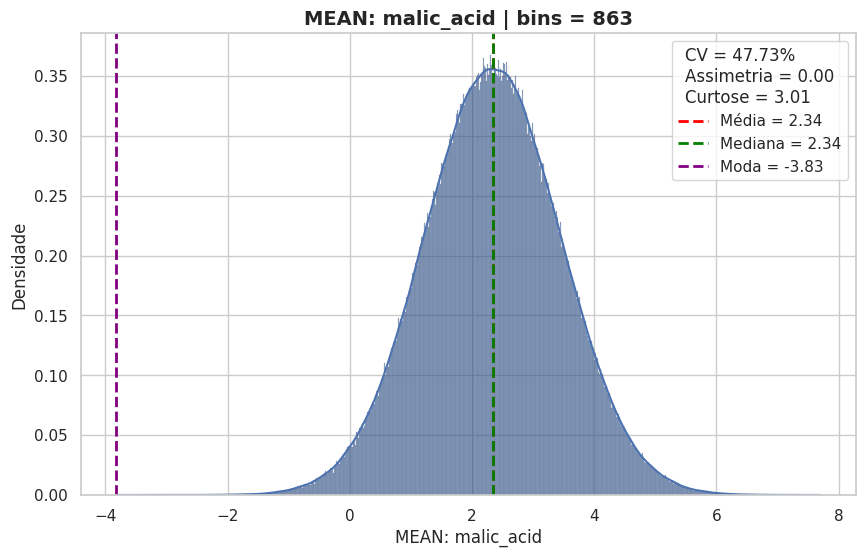

--- Diagnóstico da Distribuição: MEAN: malic_acid ---
Coeficiente de Variação = 47.73% -> alta dispersão.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.01 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: ash


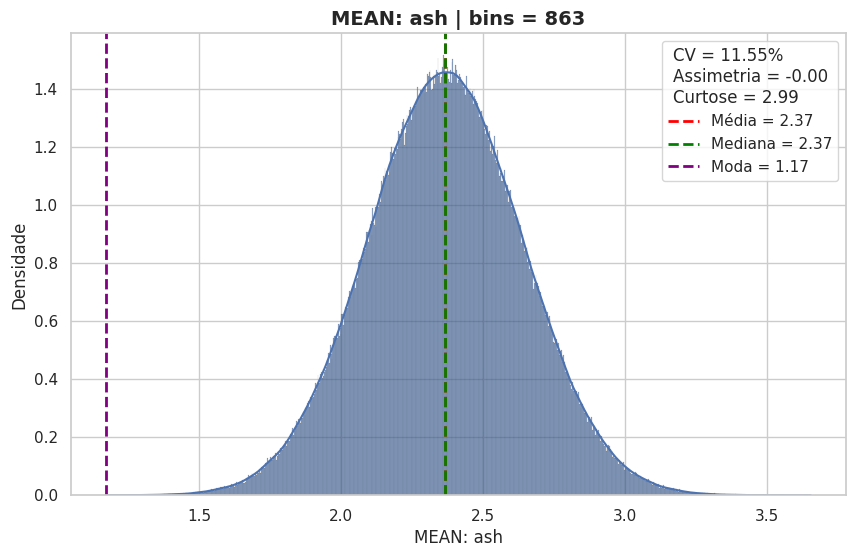

--- Diagnóstico da Distribuição: MEAN: ash ---
Coeficiente de Variação = 11.55% -> baixa dispersão.
Coeficiente de Assimetria = -0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 2.99 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: alcalinity_of_ash


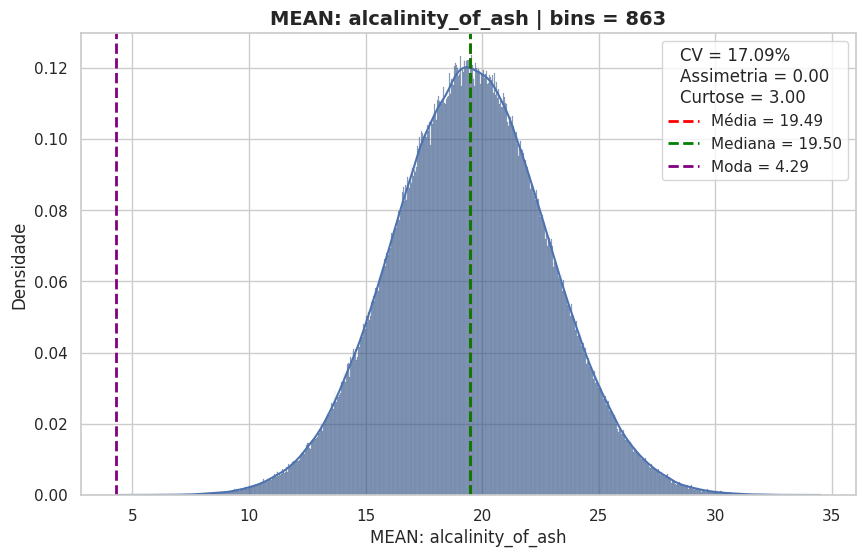

--- Diagnóstico da Distribuição: MEAN: alcalinity_of_ash ---
Coeficiente de Variação = 17.09% -> dispersão moderada.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: magnesium


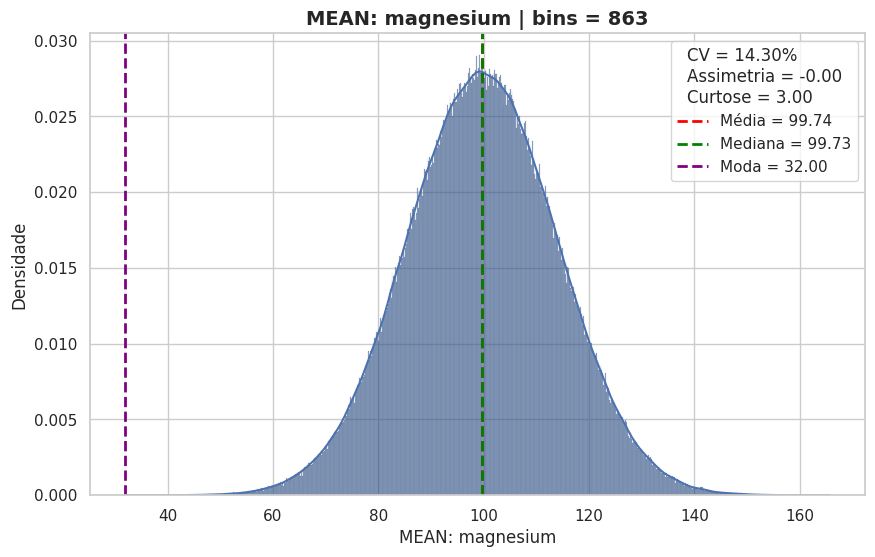

--- Diagnóstico da Distribuição: MEAN: magnesium ---
Coeficiente de Variação = 14.30% -> baixa dispersão.
Coeficiente de Assimetria = -0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: total_phenols


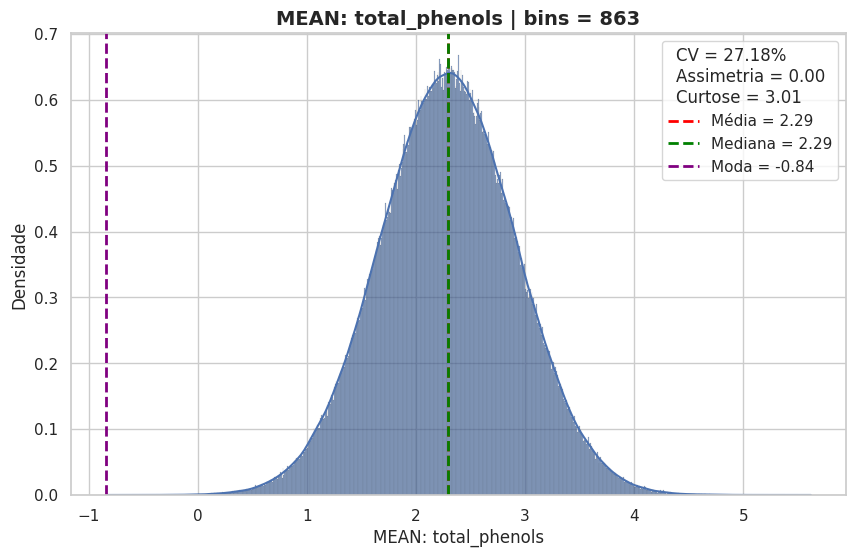

--- Diagnóstico da Distribuição: MEAN: total_phenols ---
Coeficiente de Variação = 27.18% -> dispersão moderada.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.01 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: flavanoids


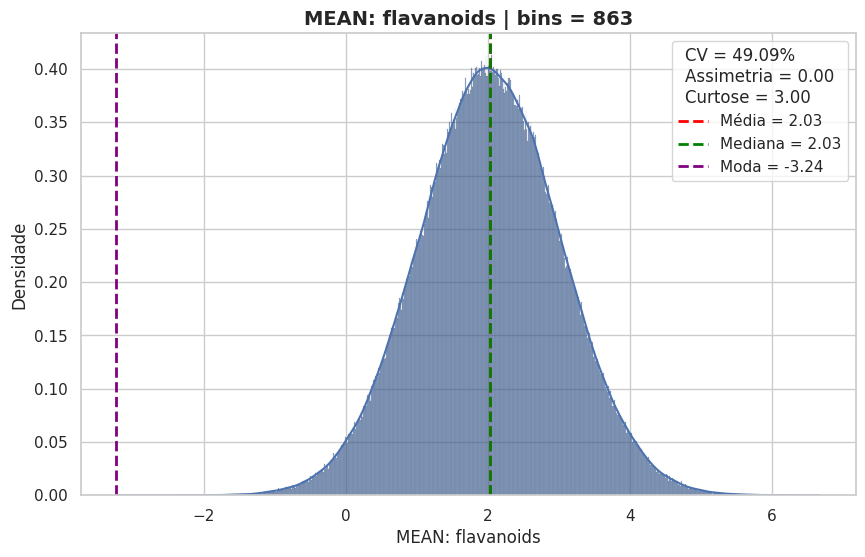

--- Diagnóstico da Distribuição: MEAN: flavanoids ---
Coeficiente de Variação = 49.09% -> alta dispersão.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: nonflavanoid_phenols


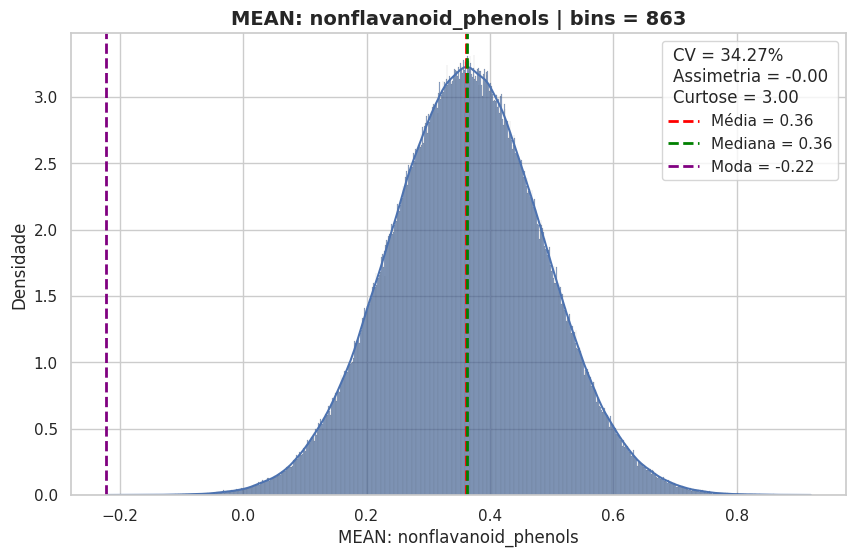

--- Diagnóstico da Distribuição: MEAN: nonflavanoid_phenols ---
Coeficiente de Variação = 34.27% -> alta dispersão.
Coeficiente de Assimetria = -0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: proanthocyanins


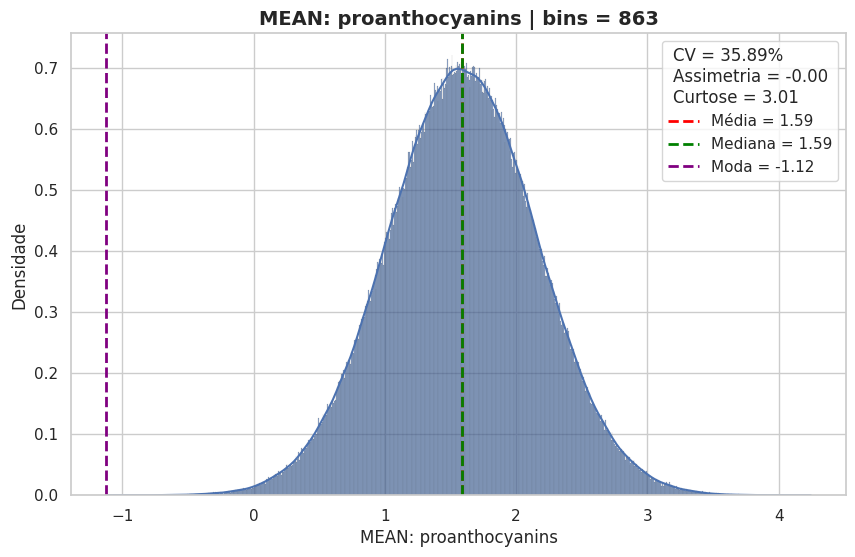

--- Diagnóstico da Distribuição: MEAN: proanthocyanins ---
Coeficiente de Variação = 35.89% -> alta dispersão.
Coeficiente de Assimetria = -0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.01 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: color_intensity


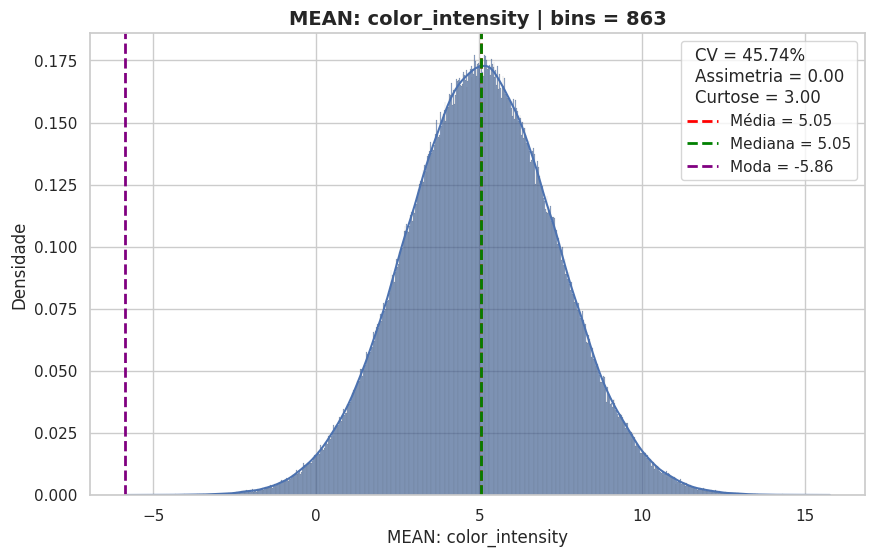

--- Diagnóstico da Distribuição: MEAN: color_intensity ---
Coeficiente de Variação = 45.74% -> alta dispersão.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: hue


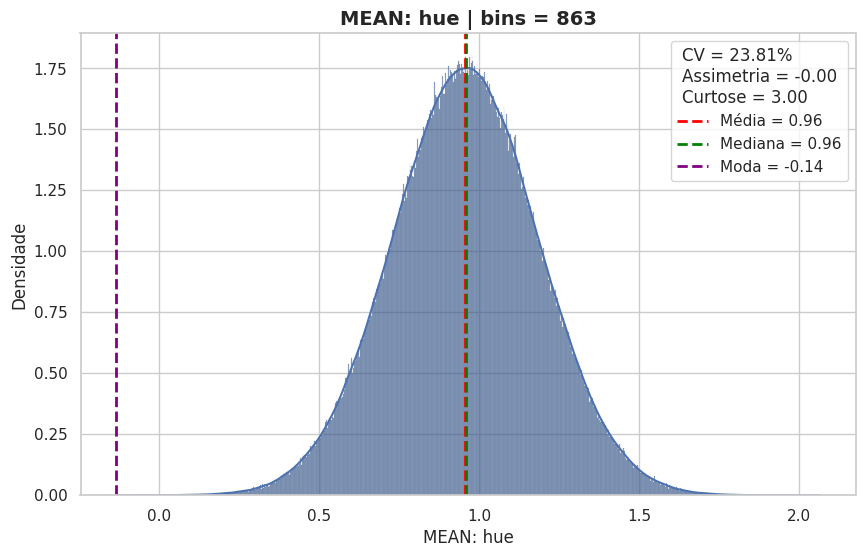

--- Diagnóstico da Distribuição: MEAN: hue ---
Coeficiente de Variação = 23.81% -> dispersão moderada.
Coeficiente de Assimetria = -0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: od280/od315_of_diluted_wines


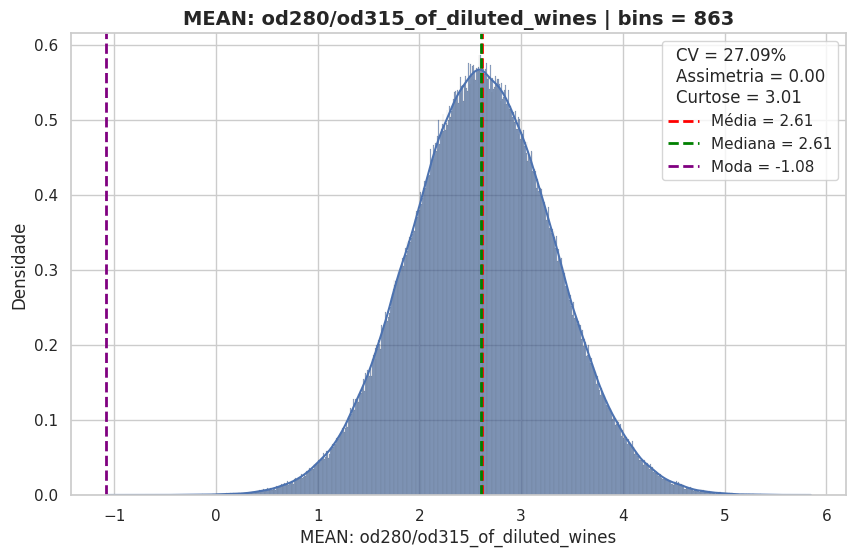

--- Diagnóstico da Distribuição: MEAN: od280/od315_of_diluted_wines ---
Coeficiente de Variação = 27.09% -> dispersão moderada.
Coeficiente de Assimetria = 0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.01 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: MEAN: proline


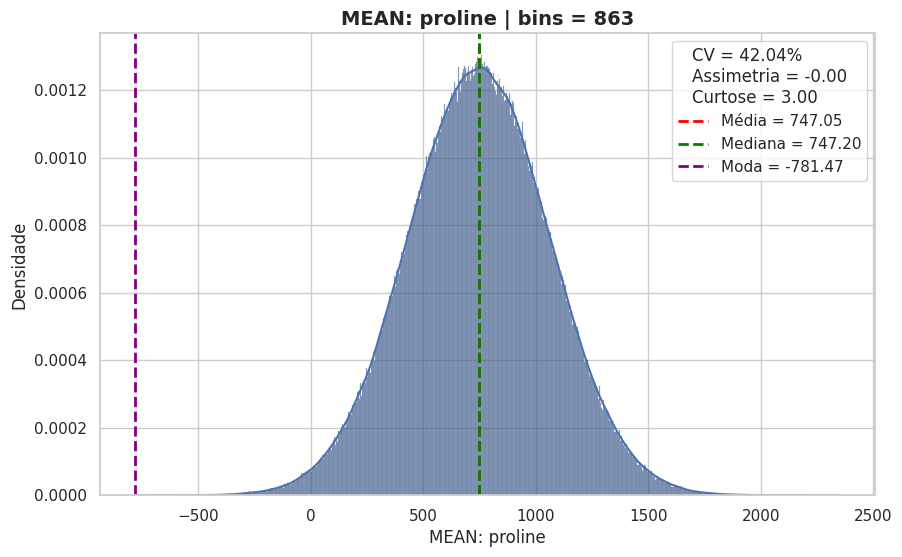

--- Diagnóstico da Distribuição: MEAN: proline ---
Coeficiente de Variação = 42.04% -> alta dispersão.
Coeficiente de Assimetria = -0.00 -> distribuição aproximadamente simétrica.
Coeficiente de Curtose = 3.00 -> distribuição mesocúrtica.
Conclusão: a distribuição se aproxima de uma normal.


Variável analisada: TOTAL (R$)


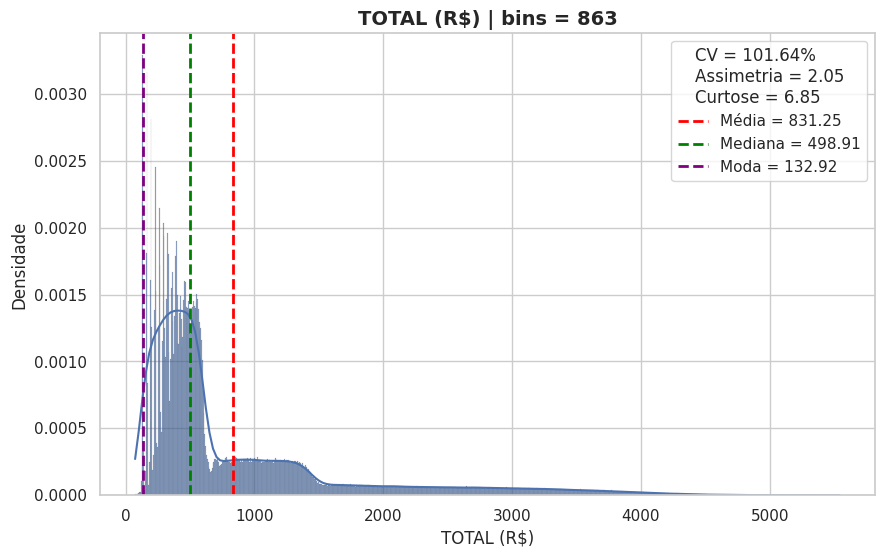

--- Diagnóstico da Distribuição: TOTAL (R$) ---
Coeficiente de Variação = 101.64% -> alta dispersão.
Coeficiente de Assimetria = 2.05 -> assimetria à direita.
Coeficiente de Curtose = 6.85 -> distribuição leptocúrtica.
Conclusão: a distribuição não se aproxima fortemente de uma normal.




In [ ]:
analyze_all_quantitative(table)

#Questão 2:

Faça uma função (**def + docstring**) que drop todos os outliers (linha inteira) desta variável quantitativa contínua qualquer do table.

Protótipo da função:

  * **def** dropOutliers(table, yLabel = None)

Aplicar nas colunas, conforme sua análise:

In [ ]:
dropOutliers(table, "RENDA BRUTO (R$)")

,NOTA FISCAL,REGIÃO,SEXO,ESTADO CIVIL,DEPENDENTES,RENDA BRUTO (R$),OPINIÃO DO CLIENTE,NOTA DE SATISFAÇÃO (%),MEAN: alcohol,MEAN: malic_acid,...,MEAN: total_phenols,MEAN: flavanoids,MEAN: nonflavanoid_phenols,MEAN: proanthocyanins,MEAN: color_intensity,MEAN: hue,MEAN: od280/od315_of_diluted_wines,MEAN: proline,TIPO DA CONTA,TOTAL (R$)
0,6876333,SUL,MASCULINO,SOLTEIRO,1,3336.84,"Serviço eficiente, recomendo o clube: UVVine",68.68,12.929435,2.447630,...,1.334842,2.236478,0.290384,1.661732,7.833947,0.952735,3.818190,276.681180,ESSENTIAL,302.31
1,5677339,SUDESTE,MASCULINO,CASADO,2,3453.34,"Serviço eficiente, recomendo o clube: UVVine",68.68,13.993214,1.393874,...,1.475983,1.676041,0.385297,1.940256,2.139143,0.910653,3.042307,377.891615,ESSENTIAL,278.26
2,1104271,SUDESTE,FEMININO,SOLTEIRO,1,3211.29,"Serviço impecável, adorei o clube: UVVine",68.68,11.161985,3.471322,...,0.820464,2.363073,0.264392,1.617888,4.953122,1.120121,3.019603,709.736181,ESSENTIAL,580.02
5,3695321,SUDESTE,MASCULINO,CASADO,2,7660.79,Entrega foi boa e rápida na UVVine,68.68,13.330639,2.779894,...,1.335875,3.080496,0.325327,0.779338,5.533546,1.218124,1.796468,565.241399,VIP,1151.11
6,6246973,SUL,MASCULINO,SOLTEIRO,0,3107.38,Gostei do atendimento prestado pela UVVine,68.68,12.747355,2.419536,...,2.117255,3.238433,0.169830,2.034443,2.643030,0.780667,3.357965,881.579413,ESSENTIAL,374.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745515,3261083,SUDESTE,MASCULINO,SOLTEIRO,0,7608.04,Gostei do atendimento prestado pela UVVine,68.68,12.705621,3.947615,...,1.960525,1.549859,0.375371,1.872563,0.169205,1.080237,1.633366,646.634506,VIP,1219.28
745516,5478633,SUL,MASCULINO,SOLTEIRO,4,7406.89,"Experiência regular, não atendeu a política de...",68.68,13.361679,3.123045,...,2.528038,2.544907,0.380590,1.671832,5.707638,0.612022,2.083445,814.741474,VIP,298.27
745518,2795181,SUL,MASCULINO,SOLTEIRO,0,7308.01,Fiquei satisfeito com o serviço da UVVine,68.68,12.513377,2.562549,...,1.977887,1.227207,0.337848,1.887877,6.699890,1.000867,2.351620,1279.428536,VIP,367.39
745521,7614280,NORTE,MASCULINO,SOLTEIRO,3,3273.68,Entrega foi boa e rápida na UVVine,68.68,13.295652,3.757052,...,2.667879,2.014052,0.192952,1.048632,5.154971,0.989338,2.916778,111.239081,ESSENTIAL,362.09


#Questão 3:

Reaplicar a função de análise, após a dropagem dos outliers para as colunas:

  * SALÁRIO BRUTO (R$)
  
  * TOTAL DE GASTOS (R$)

--- Dataset após remoção de outliers ---
Quantidade de linhas restante: 549121


Análise após remoção de outliers: RENDA BRUTO (R$)


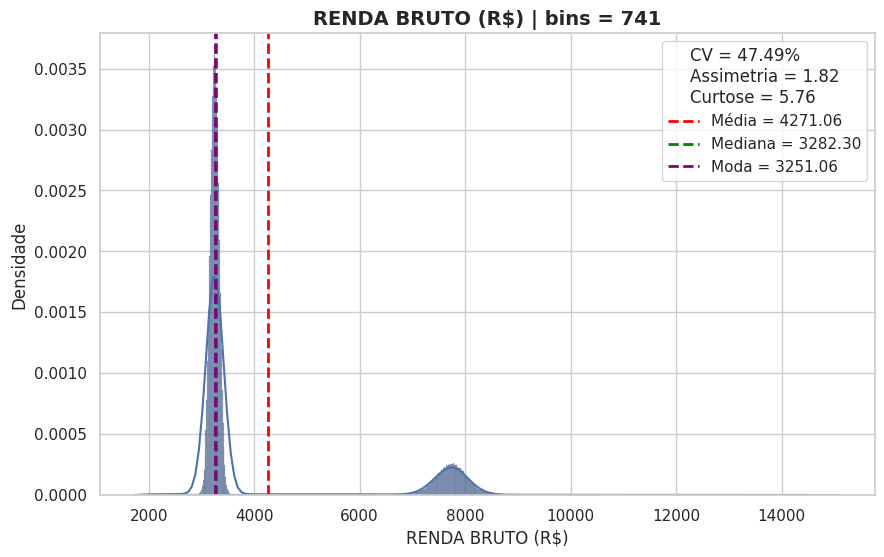

--- Diagnóstico da Distribuição: RENDA BRUTO (R$) ---
Coeficiente de Variação = 47.49% -> alta dispersão.
Coeficiente de Assimetria = 1.82 -> assimetria à direita.
Coeficiente de Curtose = 5.76 -> distribuição leptocúrtica.
Conclusão: a distribuição não se aproxima fortemente de uma normal.


Análise após remoção de outliers: TOTAL (R$)


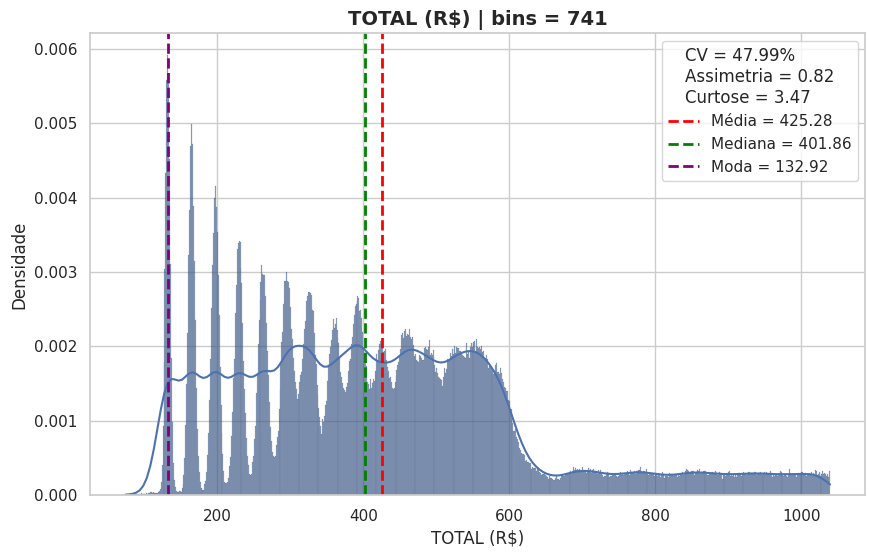

--- Diagnóstico da Distribuição: TOTAL (R$) ---
Coeficiente de Variação = 47.99% -> alta dispersão.
Coeficiente de Assimetria = 0.82 -> assimetria à direita.
Coeficiente de Curtose = 3.47 -> distribuição leptocúrtica.
Conclusão: a distribuição não se aproxima fortemente de uma normal.




In [ ]:
colunas_outliers = ["RENDA BRUTO (R$)", "TOTAL (R$)"]

table_sem_outliers = analyze_after_outlier_removal(table, colunas_outliers)

#CONCLUSÕES:

Pode-se chegar as seguintes conclusões:

* Conclusão 1

A análise gráfica das variáveis quantitativas permitiu observar o comportamento das distribuições utilizando histogramas, medidas de tendência central e métricas estatísticas. Verificou-se que algumas variáveis apresentam alta dispersão, evidenciada por coeficientes de variação elevados, como nas variáveis RENDA BRUTO (R$) e TOTAL (R$).

Além disso, várias distribuições apresentam assimetria à direita, indicando a presença de valores mais altos que distorcem a distribuição. Também foram observadas distribuições leptocúrticas, caracterizadas por maior concentração de valores próximos à média e caudas mais pesadas.

Por outro lado, algumas variáveis apresentaram comportamento aproximadamente normal, com assimetria próxima de zero e curtose próxima de 3.

* Conclusão 2


A aplicação da função de remoção de outliers utilizando o método do Intervalo Interquartil (IQR) permitiu identificar e eliminar valores extremos que poderiam distorcer a análise estatística.

Após a remoção desses valores, o dataset apresentou redução significativa no número de registros, mantendo apenas os dados considerados dentro dos limites estatísticos esperados.

Esse processo contribui para tornar as análises mais confiáveis, pois reduz o impacto de observações atípicas que podem influenciar excessivamente medidas como média, variância e distribuição dos dados.


* Conclusão 3


Após a remoção dos outliers das variáveis RENDA BRUTO (R$) e TOTAL (R$), foi realizada novamente a análise das distribuições. Observou-se uma redução na dispersão dos dados, indicando que os valores extremos estavam influenciando significativamente a variabilidade do dataset.

Entretanto, mesmo após a remoção dos outliers, algumas variáveis ainda apresentaram assimetria à direita e curtose elevada, indicando que as distribuições ainda não seguem perfeitamente uma distribuição normal.

Assim, a remoção de outliers melhora a qualidade da análise, mas não garante necessariamente que os dados passarão a apresentar comportamento totalmente normal.



PARA ENTREGAR: Converter seu YPYNB para PDF:

In [ ]:
import os

path_exercicios = '/content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios'

nome_arquivo = 'atividade2.ipynb'
caminho_entrada = os.path.join(path_exercicios, nome_arquivo)

print(f"A converter: {nome_arquivo}")
print(f"Destino: {path_exercicios}")

!jupyter nbconvert --to html "{caminho_entrada}" --output-dir="{path_exercicios}"

print("\n✅ Concluído! O ficheiro HTML foi gerado diretamente na pasta do Drive.")

A converter: atividade2.ipynb
Destino: /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios
[NbConvertApp] Converting notebook /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios/atividade2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 20 image(s).
[NbConvertApp] Writing 1929728 bytes to /content/drive/MyDrive/Sistemas-de-Informacao/6-periodo-2026.1/Estatistica-para-Ciencia-de-Dados-40h/Exercicios/atividade2.html

✅ Concluído! O ficheiro HTML foi gerado diretamente na pasta do Drive.
